# Trayectorias agregadas y composición del activo

Análisis visual del shock CERA en dos partes:

1. **Trayectorias agregadas a la Bernini et al. (2024)**: replicamos su estructura de presentación del shock — evolución del stock de depósitos USD, contraste con depósitos pesos, ventana del régimen sombreada, distribución de exposición entre bancos, balance de características pre-shock. Esto sienta las bases descriptivas.

2. **Composición intra-ME del activo (foco propio del paper)**: cómo se rebalanceó la cartera ME del banco cuando entraron los nuevos depósitos. Ésta es la lectura macroprudencial que distingue nuestro paper del de Bernini, que mira el lending channel "bruto" sin descomponer la composición.

Convenciones: saldos en valor absoluto (los pasivos vienen con signo negativo en el balance BCRA). Conversión a USD con TC A-3500 fin de mes. Panel pro-forma con consolidación Macro+BMA.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "utils"))
from paths import PANELES, DIMENSIONES, RAW, REPO

import pandas as pd
import duckdb
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import numpy as np

plt.rcParams.update({"figure.dpi": 100, "axes.grid": True, "grid.alpha": 0.3, "font.size": 10})

PANEL_BAL = PANELES / "panel_balance_mensual_proforma.parquet"
DIM_ENT = DIMENSIONES / "dim_entidades.parquet"
DIM_GRUPOS = DIMENSIONES / "dim_grupos.parquet"
FX_JSON = RAW / "bcra_api/005_tc_mayorista_a3500.json"

# Fechas clave del régimen CERA
FECHA_ANUNCIO = pd.Timestamp("2024-07-08")    # publicación BO Ley 27.743
FECHA_COM_A8062 = pd.Timestamp("2024-07-15")  # creación CERA
FECHA_CIERRE_E1 = pd.Timestamp("2024-10-31")  # cierre Etapa 1
FECHA_LIBERACION = pd.Timestamp("2025-12-31") # liberación sin retención

# Ventana del shock para análisis (estilo Bernini: shaded region)
INICIO_VENTANA = pd.Timestamp("2024-08-01")
FIN_VENTANA = pd.Timestamp("2024-10-31")

## Tipo de cambio mayorista (A-3500) fin de mes

Lo cargamos al inicio porque lo usamos en cada conversión a USD.

In [2]:
with open(FX_JSON) as f:
    fx_raw = json.load(f)
fx = pd.DataFrame(fx_raw["results"][0]["detalle"])
fx["fecha"] = pd.to_datetime(fx["fecha"])
fx["yyyymm"] = fx["fecha"].dt.strftime("%Y%m").astype(int)
fx_eom = (fx.sort_values("fecha")
            .groupby("yyyymm", as_index=False).tail(1)
            .reset_index(drop=True)[["yyyymm", "valor"]]
            .rename(columns={"valor": "tc_a3500"}))
print(f"TC A-3500 disponible: {fx_eom.yyyymm.min()} - {fx_eom.yyyymm.max()}")

TC A-3500 disponible: 201501 - 202604


## Universo de bancos y parche para HSBC

Filtramos el panel a entidades del agrupamiento institucional AA100 (bancos), criterio del BCRA. Pero `dim_grupos` se construye del último dump (202601), donde HSBC ya está absorbido por Galicia y por lo tanto no figura como banco activo. HSBC fue receptor importante de CERA durante el shock (oct-2024). Lo agregamos manualmente al universo con sigla parcheada.

El mismo procedimiento que en `01_Shock_Analysis.ipynb`.

In [3]:
bancos_df = duckdb.sql(f"""
    select distinct codigo_entidad
    from '{DIM_GRUPOS}'
    where codigo_grupo = 'AA100'
""").df()

# HSBC (00150) operó como banco independiente durante todo el peak CERA
# pero al corte del dump 202601 ya está en BAJA. Lo agregamos al universo y le
# parchamos la sigla.
BANCOS_HISTORICOS_FALTANTES = ["00150"]
BANCOS = tuple(sorted(set(bancos_df.codigo_entidad.tolist()) | set(BANCOS_HISTORICOS_FALTANTES)))

# dim_entidades_patched: copia con parches de siglas faltantes
dim_ent_full = duckdb.sql(f"select * from '{DIM_ENT}'").df()

# HSBC: estaba dado de baja al corte del dump, pero operó durante el shock
mask_hsbc = dim_ent_full["codigo_entidad"] == "00150"
if mask_hsbc.any():
    dim_ent_full.loc[mask_hsbc, "sigla"] = "HSBC"
    dim_ent_full.loc[mask_hsbc, "es_vigente"] = True

# Bancos pequeños que están vigentes en AA100 pero no tienen sigla en Nomina
SIGLAS_PARCHE = {
    "00431": "COINAG",     # Banco Coinag S.A.
    "00432": "COMERCIO",   # Banco de Comercio S.A.
}
for cod, sig in SIGLAS_PARCHE.items():
    m = dim_ent_full["codigo_entidad"] == cod
    if m.any():
        dim_ent_full.loc[m, "sigla"] = sig

# Registro la versión patchada y un panel filtrado a bancos como vistas DuckDB
duckdb.register("dim_entidades_patched", dim_ent_full)
duckdb.sql(f"""
    create or replace view panel_bancos as
    select * from '{PANEL_BAL}' where codigo_entidad in {BANCOS}
""")
print(f"Universo: {len(BANCOS)} bancos (AA100 + HSBC)")

Universo: 61 bancos (AA100 + HSBC)


# Parte 1 — Trayectorias agregadas estilo Bernini et al.

## Stock de depósitos del SPNF: USD vs pesos

Réplica conceptual de la Figura 1 de Bernini et al. La idea: mostrar (a) el flujo masivo de depósitos USD durante la ventana del régimen y (b) que los depósitos en pesos permanecen relativamente estables — argumento de que el shock es específico de USD.

In [4]:
q_dep = f"""
select yyyymm,
  sum(case when codigo_cuenta like '315%' or codigo_cuenta like '316%' then abs(saldo) else 0 end) as dep_usd,
  sum(case when codigo_cuenta like '311%' or codigo_cuenta like '312%' then abs(saldo) else 0 end) as dep_ars,
  sum(case when codigo_cuenta in ('311793','312183','315794','316147') then abs(saldo) else 0 end) as cera_total
from panel_bancos
where yyyymm >= 202401
group by yyyymm
order by yyyymm
"""
dep = duckdb.sql(q_dep).df()
dep = dep.merge(fx_eom, on="yyyymm", how="left")
dep["dep_usd_b"]   = dep["dep_usd"] / dep["tc_a3500"] / 1e9
dep["dep_ars_b"]   = dep["dep_ars"] / dep["tc_a3500"] / 1e9   # en USD-equivalentes para comparar escalas
dep["cera_b"]      = dep["cera_total"] / dep["tc_a3500"] / 1e9
dep["fecha"]       = pd.to_datetime(dep["yyyymm"].astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)
dep[["yyyymm", "dep_usd_b", "dep_ars_b", "cera_b"]].tail(8).round(2)

,yyyymm,dep_usd_b,dep_ars_b,cera_b
17,202506,33.59,112.93,3.02
18,202507,35.52,101.01,2.80
19,202508,35.18,105.97,2.64
20,202509,36.68,107.18,2.47
21,202510,37.61,100.78,2.34
22,202511,38.89,105.12,2.29
23,202512,39.90,105.06,2.27
24,202601,41.27,102.14,0.60


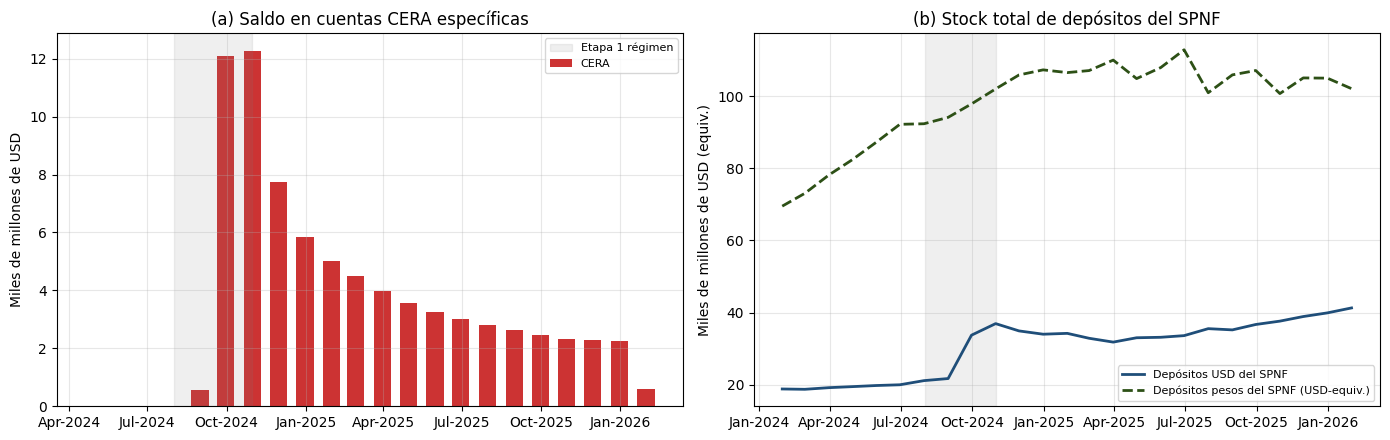

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# (a) Stock CERA específico — análogo Bernini Fig 1a
ax = axes[0]
sub = dep[dep.fecha >= "2024-04-01"]
ax.bar(sub.fecha, sub.cera_b, width=20, color="#c00000", alpha=0.8, label="CERA")
ax.axvspan(INICIO_VENTANA, FIN_VENTANA, alpha=0.12, color="gray", label="Etapa 1 régimen")
ax.set_title("(a) Saldo en cuentas CERA específicas")
ax.set_ylabel("Miles de millones de USD")
ax.legend(loc="upper right", fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))

# (b) Comparación depósitos USD vs ARS — análogo Bernini Fig 1b
ax = axes[1]
ax.plot(dep.fecha, dep.dep_usd_b, color="#1f4e79", lw=2, label="Depósitos USD del SPNF")
ax.plot(dep.fecha, dep.dep_ars_b, color="#2d5016", lw=2, ls="--", label="Depósitos pesos del SPNF (USD-equiv.)")
ax.axvspan(INICIO_VENTANA, FIN_VENTANA, alpha=0.12, color="gray")
ax.set_title("(b) Stock total de depósitos del SPNF")
ax.set_ylabel("Miles de millones de USD (equiv.)")
ax.legend(loc="best", fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))

plt.tight_layout()
plt.show()

**Lectura**: el panel (a) muestra que el grueso del flujo CERA se concentra entre ago-2024 y oct-2024 (área sombreada, Etapa 1). El panel (b) muestra que durante esa ventana los depósitos USD totales saltan ~+50% en pocos meses, mientras los depósitos en pesos no muestran movimiento equivalente. La interpretación es la misma que en Bernini: el shock es específico al lado USD del balance.

## Tasa de crecimiento mensual: USD vs pesos

Cuantificamos lo anterior. El crecimiento mensual de depósitos USD durante la ventana del régimen vs el período pre-shock.

In [6]:
dep["crec_usd_pct"] = dep["dep_usd_b"].pct_change() * 100
dep["crec_ars_pct"] = dep["dep_ars_b"].pct_change() * 100

resumen = pd.DataFrame({
    "Período": ["pre-shock (ene-jul 2024)", "ventana régimen (ago-oct 2024)", "post-régimen (12m)"],
    "Crec. mensual USD (%)": [
        dep[(dep.fecha >= "2024-01-01") & (dep.fecha < "2024-08-01")]["crec_usd_pct"].mean(),
        dep[(dep.fecha >= INICIO_VENTANA) & (dep.fecha <= FIN_VENTANA)]["crec_usd_pct"].mean(),
        dep[(dep.fecha > FIN_VENTANA) & (dep.fecha <= "2025-10-31")]["crec_usd_pct"].mean(),
    ],
    "Crec. mensual ARS (%)": [
        dep[(dep.fecha >= "2024-01-01") & (dep.fecha < "2024-08-01")]["crec_ars_pct"].mean(),
        dep[(dep.fecha >= INICIO_VENTANA) & (dep.fecha <= FIN_VENTANA)]["crec_ars_pct"].mean(),
        dep[(dep.fecha > FIN_VENTANA) & (dep.fecha <= "2025-10-31")]["crec_ars_pct"].mean(),
    ]
}).round(2)
resumen

,Período,Crec. mensual USD (%),Crec. mensual ARS (%)
0,pre-shock (ene-jul 2024),1.98,4.88
1,ventana régimen (ago-oct 2024),22.60,3.38
2,post-régimen (12m),0.21,0.00


## Heterogeneidad del shock entre bancos

Distribución de la exposición banco-nivel: CERA peak / depósitos totales pre-shock. Esta es la métrica de Bernini (su sec. 4.1) para mostrar variación cross-section del shock.

In [7]:
q_expo = f"""
with cera_peak as (
    select codigo_entidad, abs(sum(saldo)) as cera_peak
    from panel_bancos
    where codigo_cuenta in ('311793','312183','315794','316147')
      and yyyymm = 202410
    group by codigo_entidad
),
dep_pre as (
    select codigo_entidad, abs(sum(saldo)) as dep_total_pre
    from panel_bancos
    where (codigo_cuenta like '311%' or codigo_cuenta like '312%'
        or codigo_cuenta like '315%' or codigo_cuenta like '316%')
      and yyyymm = 202406
    group by codigo_entidad
    having dep_total_pre > 0
)
select c.codigo_entidad, c.cera_peak, d.dep_total_pre,
       c.cera_peak / d.dep_total_pre as exposicion
from cera_peak c
join dep_pre d using (codigo_entidad)
where c.cera_peak > 0
order by exposicion desc
"""
expo = duckdb.sql(q_expo).df()

# Sigla
nombres = duckdb.sql(f"select codigo_entidad, sigla, nombre from dim_entidades_patched where es_vigente").df()
expo = expo.merge(nombres, on="codigo_entidad", how="left")
print(f"Bancos con CERA > 0 y depósitos pre-shock > 0: {len(expo)}")
print(f"Mediana exposición: {expo.exposicion.median()*100:.2f}%")
print(f"P25: {expo.exposicion.quantile(0.25)*100:.2f}%   P75: {expo.exposicion.quantile(0.75)*100:.2f}%")
print(f"Máxima: {expo.exposicion.max()*100:.2f}% ({expo.iloc[0].sigla or expo.iloc[0].codigo_entidad})")
expo.head(10)[["codigo_entidad", "sigla", "exposicion"]].assign(exposicion=lambda d: (d.exposicion*100).round(2))

Bancos con CERA > 0 y depósitos pre-shock > 0: 42
Mediana exposición: 4.16%
P25: 2.31%   P75: 13.08%
Máxima: 39.85% (COMERCIO)


,codigo_entidad,sigla,exposicion
0,00432,COMERCIO,39.85
1,00072,SANTAND,38.39
2,00007,GALICIA,35.41
3,00431,COINAG,27.03
4,00017,BBVA.AR,25.01
5,00285,MACRO,20.58
6,00319,METR_FI,19.23
7,00015,INDUSTR,15.20
8,00426,BICA,15.19
9,00027,SUPERVI,13.87


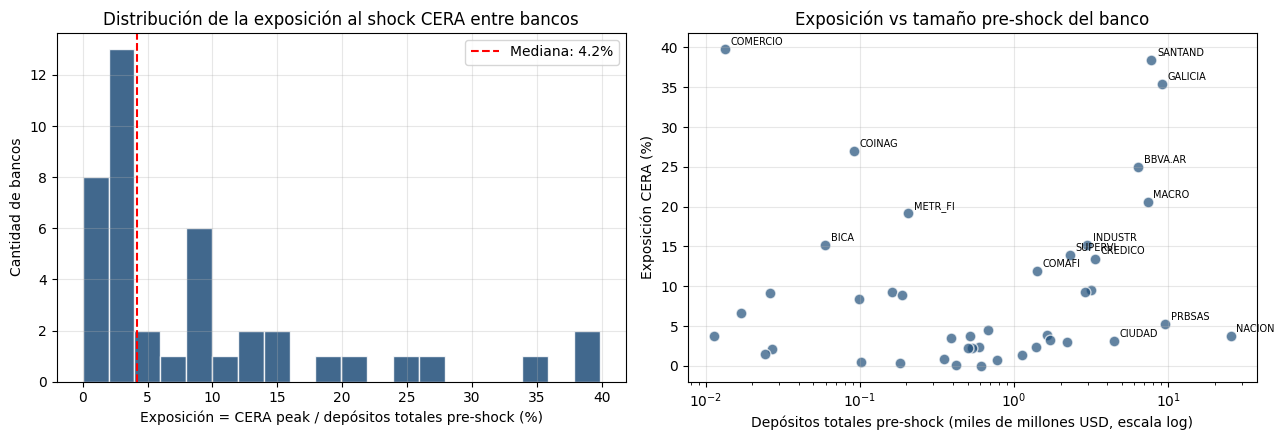

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Histograma de exposición
ax = axes[0]
ax.hist(expo.exposicion * 100, bins=20, color="#1f4e79", alpha=0.85, edgecolor="white")
ax.axvline(expo.exposicion.median() * 100, ls="--", color="red", label=f"Mediana: {expo.exposicion.median()*100:.1f}%")
ax.set_xlabel("Exposición = CERA peak / depósitos totales pre-shock (%)")
ax.set_ylabel("Cantidad de bancos")
ax.set_title("Distribución de la exposición al shock CERA entre bancos")
ax.legend()

# Scatter exposición vs tamaño pre-shock (depósitos totales)
ax = axes[1]
expo["dep_pre_b_usd"] = expo["dep_total_pre"] / fx_eom.loc[fx_eom.yyyymm == 202406, "tc_a3500"].iloc[0] / 1e9
ax.scatter(expo.dep_pre_b_usd, expo.exposicion * 100, s=60, alpha=0.7, color="#1f4e79", edgecolor="white")
for _, row in expo.iterrows():
    if row.exposicion > 0.10 or row.dep_pre_b_usd > 4:
        label = row.sigla if pd.notna(row.sigla) else row.codigo_entidad
        ax.annotate(str(label)[:8], (row.dep_pre_b_usd, row.exposicion * 100), fontsize=7,
                    xytext=(4, 3), textcoords="offset points")
ax.set_xscale("log")
ax.set_xlabel("Depósitos totales pre-shock (miles de millones USD, escala log)")
ax.set_ylabel("Exposición CERA (%)")
ax.set_title("Exposición vs tamaño pre-shock del banco")

plt.tight_layout()
plt.show()

**Lectura**: la distribución es muy dispersa — algunos bancos no recibieron prácticamente nada y otros recibieron el equivalente al 30%+ de sus depósitos preexistentes. El scatter de la derecha muestra que la exposición no está mecánicamente determinada por el tamaño — hay bancos chicos con alta exposición y grandes con baja. Esa variación cross-section es lo que sostiene la identificación.

## Test de balance: características pre-shock por cuartil de exposición

Estilo Bernini sec. 4.1: comparar características observables entre bancos más y menos expuestos antes del shock. Si el balance se cumple, los grupos son comparables y la asignación del shock es plausiblemente exógena al condicional al tamaño.

In [9]:
# Cuartiles de exposición
expo["cuartil"] = pd.qcut(expo.exposicion, q=4, labels=["Q1 (baja)", "Q2", "Q3", "Q4 (alta)"])

# Para cada banco, traigo características pre-shock (jun-2024)
q_chars = f"""
select codigo_entidad,
  abs(sum(case when codigo_cuenta like '1%' then saldo else 0 end)) as activo_total,
  abs(sum(case when codigo_cuenta like '315%' or codigo_cuenta like '316%' then saldo else 0 end)) as dep_usd,
  abs(sum(case when codigo_cuenta like '311%' or codigo_cuenta like '312%' then saldo else 0 end)) as dep_ars,
  abs(sum(case when codigo_cuenta like '135%' then saldo else 0 end)) as cred_me_residentes_pais,
  abs(sum(case when codigo_cuenta like '131%' then saldo else 0 end)) as cred_ars_residentes_pais,
  abs(sum(case when codigo_cuenta like '125%' then saldo else 0 end)) as titulos_me,
  abs(sum(case when codigo_cuenta like '115%' then saldo else 0 end)) as efectivo_me,
  abs(sum(case when codigo_cuenta = '400000' or codigo_cuenta = '500000' or codigo_cuenta = '650000' then saldo else 0 end)) as patrimonio_neto
from panel_bancos
where yyyymm = 202406
group by codigo_entidad
"""
chars = duckdb.sql(q_chars).df()
chars = chars.merge(expo[["codigo_entidad", "exposicion", "cuartil"]], on="codigo_entidad", how="inner")

# Ratios y conversión a USD para escala
tc = fx_eom.loc[fx_eom.yyyymm == 202406, "tc_a3500"].iloc[0]
chars["activo_b_usd"] = chars["activo_total"] / tc / 1e9
chars["share_dep_usd"] = chars["dep_usd"] / (chars["dep_usd"] + chars["dep_ars"])
chars["share_cred_me"] = chars["cred_me_residentes_pais"] / (chars["cred_me_residentes_pais"] + chars["cred_ars_residentes_pais"]).replace(0, np.nan)
chars["share_titulos_me_act"] = chars["titulos_me"] / chars["activo_total"]
chars["pn_sobre_activo"] = chars["patrimonio_neto"] / chars["activo_total"]

balance = chars.groupby("cuartil", observed=True).agg(
    n_bancos=("codigo_entidad", "count"),
    activo_b_usd=("activo_b_usd", "median"),
    share_dep_usd_pct=("share_dep_usd", lambda x: x.median() * 100),
    share_cred_me_pct=("share_cred_me", lambda x: x.median() * 100),
    share_titulos_me_pct=("share_titulos_me_act", lambda x: x.median() * 100),
    pn_sobre_activo_pct=("pn_sobre_activo", lambda x: x.median() * 100),
).round(2)
balance

,n_bancos,activo_b_usd,share_dep_usd_pct,share_cred_me_pct,share_titulos_me_pct,pn_sobre_activo_pct
cuartil,,,,,,
Q1 (baja),11,0.63,6.30,1.65,3.48,0.0
Q2,10,2.22,8.90,8.71,3.56,0.0
Q3,10,0.76,18.32,3.25,2.77,0.0
Q4 (alta),11,5.89,23.14,13.15,2.87,0.0


**Lectura**: comparamos las medianas por cuartil de exposición. El cuartil 4 (más expuesto) tiende a ser más grande y a tener mayor share USD pre-shock — esperable y consistente con Bernini ("more dollar-deposit-heavy banks got more amnesty inflows"). La pregunta para identificación es si esta diferencia es controlable con efectos fijos de tamaño + share USD pre-shock. La sección 5 (no incluida acá) lo formalizaría con regresión.

## Pre-tendencias agregadas: ene 2024 a jul 2024

La ventana pre arranca en ene-2024 deliberadamente. La devaluación de dic-2023 (TC oficial salta de ~365 a ~800 ARS/USD con el cambio de gobierno) marcó un quiebre macro mayor; cualquier dato anterior pertenece a un régimen distinto y no es comparable. Verificamos que en el período ene-jul 2024 (post-devaluación, pre-anuncio del blanqueo) no hay anticipación visible en los depósitos USD.

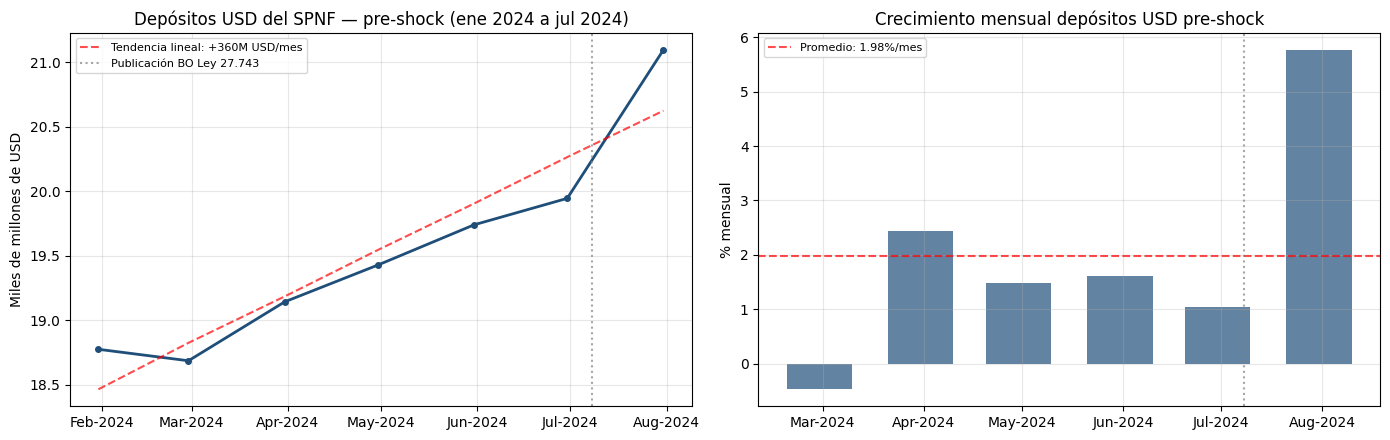

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

# Stock USD pre-shock con regresión lineal
sub = dep[(dep.fecha >= "2024-01-01") & (dep.fecha <= "2024-07-31")]
ax = axes[0]
ax.plot(sub.fecha, sub.dep_usd_b, color="#1f4e79", lw=2, marker="o", ms=4)
# tendencia lineal pre
x = np.arange(len(sub))
if len(sub) > 2:
    coef = np.polyfit(x, sub.dep_usd_b, 1)
    ax.plot(sub.fecha, np.polyval(coef, x), ls="--", color="red", alpha=0.7,
            label=f"Tendencia lineal: +{coef[0]*1000:.0f}M USD/mes")
ax.axvline(FECHA_ANUNCIO, ls=":", color="gray", alpha=0.7, label="Publicación BO Ley 27.743")
ax.set_title("Depósitos USD del SPNF — pre-shock (ene 2024 a jul 2024)")
ax.set_ylabel("Miles de millones de USD")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))

# Tasa de crecimiento mensual
ax = axes[1]
ax.bar(sub.fecha, sub.crec_usd_pct, width=20, color="#1f4e79", alpha=0.7)
ax.axhline(sub.crec_usd_pct.mean(), ls="--", color="red", alpha=0.7,
           label=f"Promedio: {sub.crec_usd_pct.mean():.2f}%/mes")
ax.axvline(FECHA_ANUNCIO, ls=":", color="gray", alpha=0.7)
ax.set_title("Crecimiento mensual depósitos USD pre-shock")
ax.set_ylabel("% mensual")
ax.legend(fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))

plt.tight_layout()
plt.show()

La tendencia pre-shock es de crecimiento sostenido pero no acelerado — la ley se anuncia el 8-jul-2024 y el grueso del flujo aparece desde ago-2024 en adelante. No hay un salto visible en jun-jul 2024 que sugiera anticipación material. Esta verificación es análoga a los pre-trends tests de Bernini sec. 4.

# Parte 2 — Composición del activo en moneda extranjera

Acá entramos en el foco propio del paper. Una vez verificado que el shock está bien identificado y es exógeno al banco condicional a tamaño, miramos cómo el banco rebalanceó su activo ME bajo las restricciones macroprudenciales (matching ME, encaje 25%, tope 1/3 Tesoro, PGNME piso −30%).

## Composición intra-ME del sistema agregado

Agregamos los activos en ME de todos los bancos (panel pro-forma, sin agrupamientos AAxxx) y descomponemos por canal del menú regulatorio.

In [11]:
q_canales = f"""
select yyyymm,
  sum(case when codigo_cuenta like '115%' then abs(saldo) else 0 end) as encaje_efectivo_me,
  sum(case when codigo_cuenta in ('125003','125016','125042','125090') then abs(saldo) else 0 end) as tesoro_usd,
  sum(case when codigo_cuenta in ('125036','125038','125039','125041','125043','125044','125058','125059') then abs(saldo) else 0 end) as letras_notas_bcra_me,
  sum(case when codigo_cuenta like '1357%' or codigo_cuenta like '1358%' then abs(saldo) else 0 end) as credito_me_spnf,
  sum(case when codigo_cuenta like '1354%' or codigo_cuenta like '1355%' then abs(saldo) else 0 end) as interbancario_dom_me,
  sum(case when codigo_cuenta like '1351%' or codigo_cuenta like '1352%' then abs(saldo) else 0 end) as credito_me_sp,
  sum(case when codigo_cuenta like '136%' then abs(saldo) else 0 end) as crossborder_me,
  sum(case when codigo_cuenta like '145%' or codigo_cuenta like '155%' or codigo_cuenta like '175%' then abs(saldo) else 0 end) as otros_me
from panel_bancos
where yyyymm >= 202401
group by yyyymm
order by yyyymm
"""
saldos = duckdb.sql(q_canales).df()
cols_me = ["encaje_efectivo_me", "tesoro_usd", "letras_notas_bcra_me",
           "credito_me_spnf", "interbancario_dom_me", "credito_me_sp",
           "crossborder_me", "otros_me"]
saldos["total_me"] = saldos[cols_me].sum(axis=1)
shares = saldos[cols_me].div(saldos["total_me"], axis=0)
shares["fecha"] = pd.to_datetime(saldos["yyyymm"].astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)

labels = {
    "encaje_efectivo_me": "Encaje y efectivo BCRA (cap. 115)",
    "tesoro_usd": "Tesoro USD (subset cap. 125)",
    "letras_notas_bcra_me": "Letras/Notas BCRA en ME (subset cap. 125)",
    "credito_me_spnf": "Crédito ME a SPNF (1357+1358)",
    "interbancario_dom_me": "Interbancario doméstico ME (1354+1355)",
    "credito_me_sp": "Crédito ME a Sector Público (1351+1352)",
    "crossborder_me": "Crédito ME crossborder (cap. 136)",
    "otros_me": "Otros activos ME (cap. 145+155+175)",
}
colores = ["#4472c4", "#264478", "#5b9bd5",
           "#70ad47", "#a5d08c", "#7d4f1c",
           "#ed7d31", "#a5a5a5"]

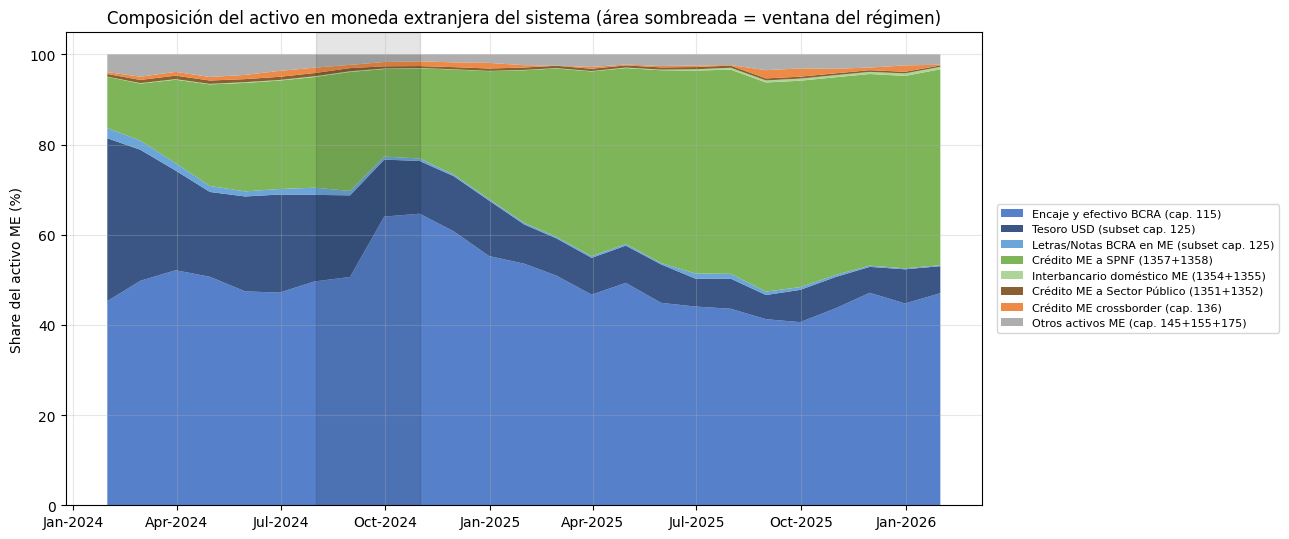

In [12]:
fig, ax = plt.subplots(figsize=(13, 5.5))
ax.stackplot(shares.fecha, *[shares[c] * 100 for c in cols_me],
             labels=[labels[c] for c in cols_me], colors=colores, alpha=0.9)
ax.axvspan(INICIO_VENTANA, FIN_VENTANA, alpha=0.10, color="black")
ax.set_ylim(0, 105)
ax.set_ylabel("Share del activo ME (%)")
ax.set_title("Composición del activo en moneda extranjera del sistema (área sombreada = ventana del régimen)")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))
plt.tight_layout()
plt.show()

## Cada canal por separado

Líneas individuales para identificar discontinuidades en cada categoría. La línea roja punteada marca la creación de la CERA (15-jul-2024); la naranja, el cierre de Etapa 1 (31-oct-2024).

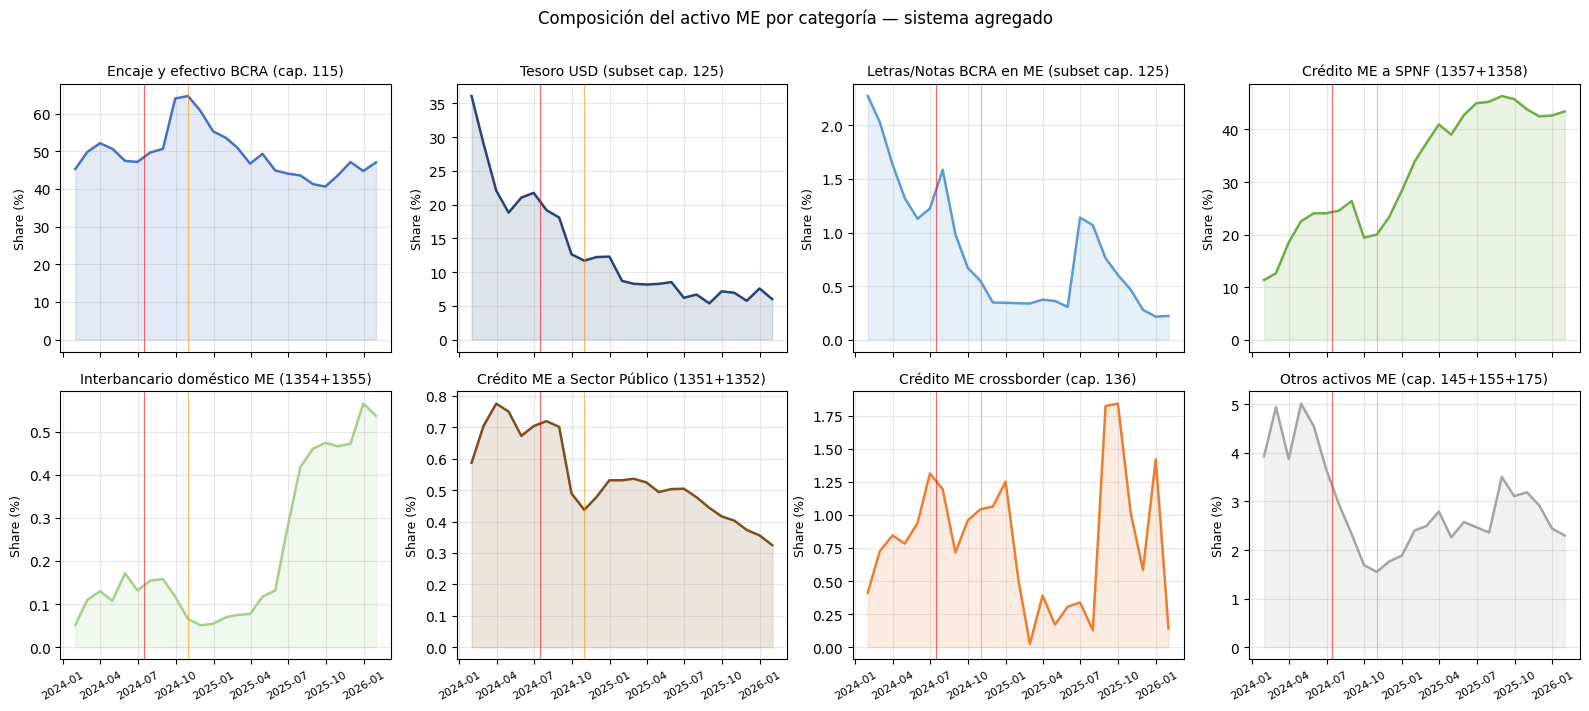

In [13]:
fig, axes = plt.subplots(2, 4, figsize=(16, 7), sharex=True)
axes = axes.flatten()
for ax, col, color in zip(axes, cols_me, colores):
    serie = shares[col] * 100
    ax.plot(shares.fecha, serie, color=color, lw=1.8)
    ax.fill_between(shares.fecha, serie, alpha=0.15, color=color)
    ax.axvline(FECHA_COM_A8062, color="red", lw=0.8, alpha=0.6)
    ax.axvline(FECHA_CIERRE_E1, color="darkorange", lw=0.8, alpha=0.6)
    ax.set_title(labels[col], fontsize=10)
    ax.set_ylabel("Share (%)", fontsize=9)
    ax.tick_params(axis="x", labelrotation=30, labelsize=8)
plt.suptitle("Composición del activo ME por categoría — sistema agregado", fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

## Comparación pre vs post: 7 meses pre vs 7 meses post

Ventanas simétricas para garantizar paralelismo. La pre arranca en ene-2024 (post-devaluación de dic-2023, primer mes con régimen macro estable bajo el nuevo gobierno) y va hasta jul-2024 (último mes antes del shock CERA). La post va de ago-2024 a feb-2025: 7 meses que incluyen el peak (oct-2024) y el período inicial de reclasificación CERA → depósitos USD regulares.

In [14]:
pre = shares[(shares.fecha >= "2024-01-01") & (shares.fecha <= "2024-07-31")][cols_me].mean() * 100
post = shares[(shares.fecha >= "2024-08-01") & (shares.fecha <= "2025-02-28")][cols_me].mean() * 100
delta = post - pre

comp = pd.DataFrame({"pre (7m)": pre, "post (7m)": post, "delta (pp)": delta}).round(2)
comp.index = [labels[c] for c in cols_me]
comp.sort_values("delta (pp)", ascending=False)

,pre (7m),post (7m),delta (pp)
Encaje y efectivo BCRA (cap. 115),48.88,57.12,8.25
Crédito ME a SPNF (1357+1358),19.67,26.95,7.28
Interbancario doméstico ME (1354+1355),0.12,0.08,-0.04
Crédito ME crossborder (cap. 136),0.89,0.79,-0.09
Crédito ME a Sector Público (1351+1352),0.70,0.53,-0.17
Letras/Notas BCRA en ME (subset cap. 125),1.60,0.51,-1.09
Otros activos ME (cap. 145+155+175),4.13,2.02,-2.12
Tesoro USD (subset cap. 125),24.01,11.99,-12.02


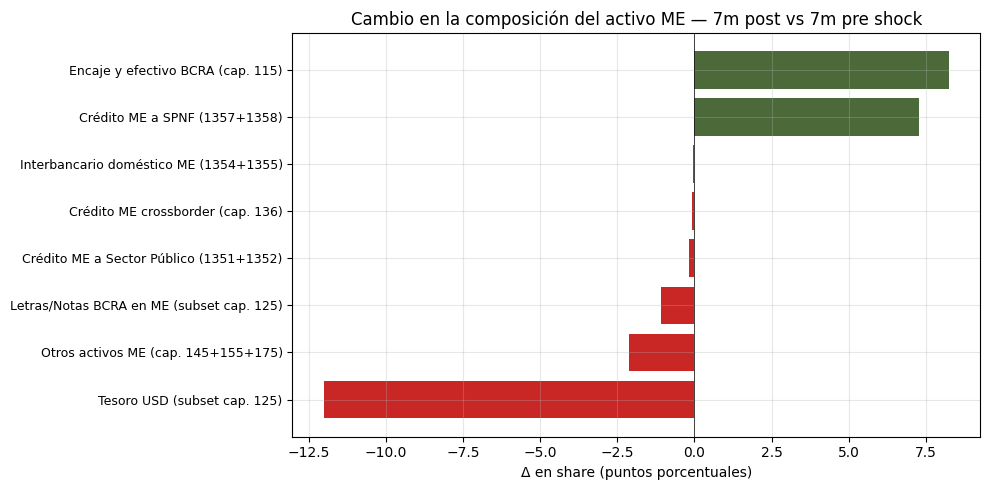

In [15]:
fig, ax = plt.subplots(figsize=(10, 5))
order = delta.sort_values().index.tolist()
delta_o = delta.loc[order]
labels_o = [labels[c] for c in order]
colores_d = ["#c00000" if v < 0 else "#2d5016" for v in delta_o]
y = np.arange(len(order))
ax.barh(y, delta_o, color=colores_d, alpha=0.85)
ax.set_yticks(y)
ax.set_yticklabels(labels_o, fontsize=9)
ax.axvline(0, color="black", lw=0.5)
ax.set_xlabel("Δ en share (puntos porcentuales)")
ax.set_title("Cambio en la composición del activo ME — 7m post vs 7m pre shock")
plt.tight_layout()
plt.show()

## Dolarización del balance

Mirar lo mismo desde el ángulo del balance total: ¿cuánto cambió el peso del lado ME en el balance bancario?

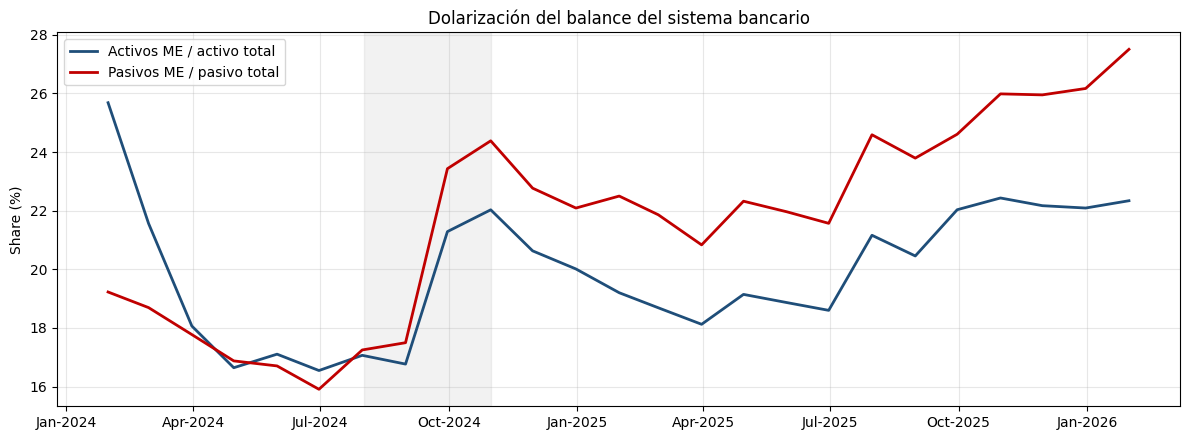

,yyyymm,share_act_me,share_pas_me
17,202506,18.60,21.57
18,202507,21.16,24.59
19,202508,20.46,23.79
20,202509,22.03,24.61
21,202510,22.43,25.99
22,202511,22.17,25.95
23,202512,22.09,26.17
24,202601,22.34,27.51


In [16]:
q_dol = f"""
select yyyymm,
  sum(case when codigo_cuenta like '115%' or codigo_cuenta like '116%'
            or codigo_cuenta like '125%' or codigo_cuenta like '126%'
            or codigo_cuenta like '135%' or codigo_cuenta like '136%'
            or codigo_cuenta like '145%' or codigo_cuenta like '146%'
            or codigo_cuenta like '155%' or codigo_cuenta like '175%' or codigo_cuenta like '176%'
        then abs(saldo) else 0 end) as activos_me,
  sum(case when codigo_cuenta like '1%' then abs(saldo) else 0 end) as activos_total,
  sum(case when codigo_cuenta like '315%' or codigo_cuenta like '316%'
            or codigo_cuenta like '325%' or codigo_cuenta like '326%'
        then abs(saldo) else 0 end) as pasivos_me,
  sum(case when codigo_cuenta like '3%' or codigo_cuenta like '2%'
        then abs(saldo) else 0 end) as pasivos_total
from panel_bancos
where yyyymm >= 202401
group by yyyymm
order by yyyymm
"""
dolariz = duckdb.sql(q_dol).df()
dolariz["share_act_me"] = dolariz["activos_me"] / dolariz["activos_total"] * 100
dolariz["share_pas_me"] = dolariz["pasivos_me"] / dolariz["pasivos_total"] * 100
dolariz["fecha"] = pd.to_datetime(dolariz["yyyymm"].astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)

fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(dolariz.fecha, dolariz.share_act_me, lw=2, color="#1f4e79", label="Activos ME / activo total")
ax.plot(dolariz.fecha, dolariz.share_pas_me, lw=2, color="#c00000", label="Pasivos ME / pasivo total")
ax.axvspan(INICIO_VENTANA, FIN_VENTANA, alpha=0.10, color="gray")
ax.set_ylabel("Share (%)")
ax.set_title("Dolarización del balance del sistema bancario")
ax.legend(loc="best")
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))
plt.tight_layout()
plt.show()
dolariz[["yyyymm", "share_act_me", "share_pas_me"]].tail(8).round(2)

## Heterogeneidad por banco — composición de los más expuestos

Spaghetti de la share del crédito ME a SPNF (la categoría más relevante del paper) para los 10 bancos más expuestos al shock CERA. Cada línea es un banco; el promedio del top-10 ponderado por activos ME va en negro grueso.

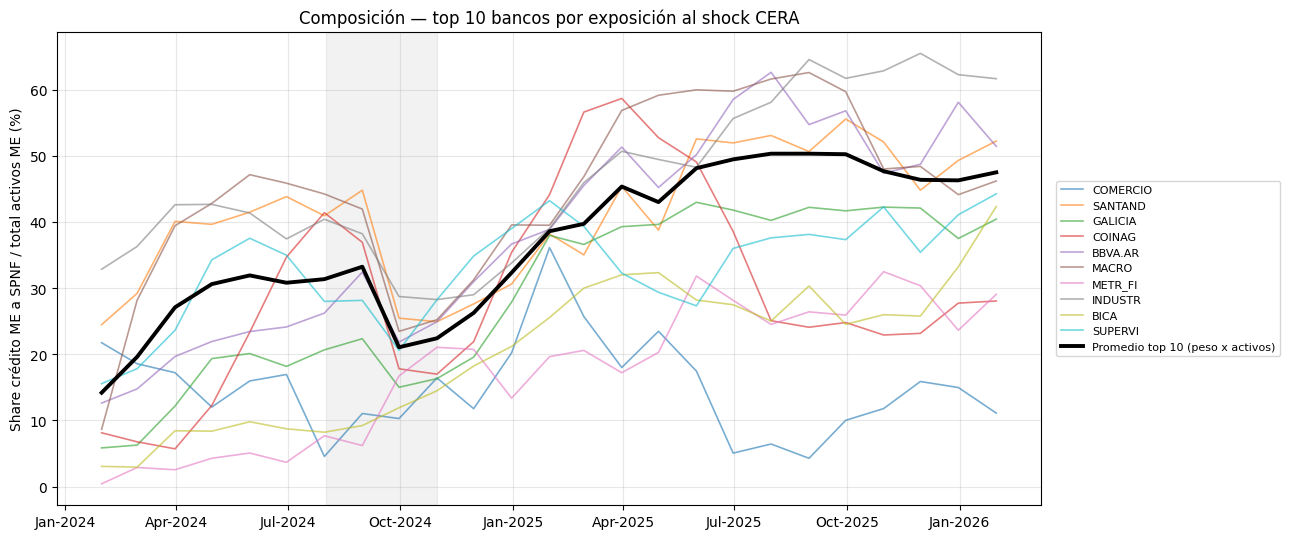

In [17]:
top10 = expo.head(10)["codigo_entidad"].tolist()

q_banco = f"""
select codigo_entidad, yyyymm,
  sum(case when codigo_cuenta like '1357%' or codigo_cuenta like '1358%' then abs(saldo) else 0 end) as credito_me_spnf,
  sum(case when codigo_cuenta like '115%' or codigo_cuenta like '125%' or codigo_cuenta like '135%'
            or codigo_cuenta like '136%' or codigo_cuenta like '145%' or codigo_cuenta like '155%'
            or codigo_cuenta like '175%' then abs(saldo) else 0 end) as activos_me_total
from panel_bancos
where yyyymm >= 202401 and codigo_entidad in {tuple(top10)}
group by codigo_entidad, yyyymm
"""
sb = duckdb.sql(q_banco).df()
sb = sb[sb.activos_me_total > 0].copy()
sb["share_spnf"] = sb["credito_me_spnf"] / sb["activos_me_total"] * 100
sb["fecha"] = pd.to_datetime(sb["yyyymm"].astype(str), format="%Y%m") + pd.offsets.MonthEnd(0)
nombres_dict = nombres.set_index("codigo_entidad")["sigla"].to_dict()

fig, ax = plt.subplots(figsize=(13, 5.5))
for cod in top10:
    sub = sb[sb.codigo_entidad == cod].sort_values("fecha")
    if len(sub):
        ax.plot(sub.fecha, sub.share_spnf, lw=1.2, alpha=0.6, label=nombres_dict.get(cod, cod))

# Promedio top 10 (ponderado por activos)
sistema_top10 = sb.groupby("fecha")[["credito_me_spnf", "activos_me_total"]].sum().reset_index()
sistema_top10["share_spnf"] = sistema_top10["credito_me_spnf"] / sistema_top10["activos_me_total"] * 100
ax.plot(sistema_top10.fecha, sistema_top10.share_spnf, lw=2.8, color="black", label="Promedio top 10 (peso x activos)")

ax.axvspan(INICIO_VENTANA, FIN_VENTANA, alpha=0.10, color="gray")
ax.set_ylabel("Share crédito ME a SPNF / total activos ME (%)")
ax.set_title("Composición — top 10 bancos por exposición al shock CERA")
ax.legend(loc="center left", bbox_to_anchor=(1.01, 0.5), fontsize=8)
ax.xaxis.set_major_formatter(mdates.DateFormatter("%b-%Y"))
plt.tight_layout()
plt.show()

# Síntesis provisoria

Tres lecturas a contrastar después con regresiones formales:

1. **El shock está identificado limpio**. Los depósitos USD saltan +50% en la ventana del régimen mientras los pesos no se mueven. La pre-tendencia no muestra anticipación material previa al 8-jul-2024 (publicación BO).

2. **El shock se distribuyó muy heterogéneamente entre bancos**. Algunos recibieron CERA equivalente al 30%+ de sus depósitos preexistentes; otros, casi nada. La exposición está correlacionada con tamaño y dolarización pre-shock pero no es mecánica — hay variación residual identificadora.

3. **La composición intra-ME del activo cambió bruscamente**. El crédito ME al SPNF gana ~9 puntos porcentuales del activo ME; el Tesoro USD pierde ~11; el encaje BCRA gana ~6. Esto es **rebalanceo activo del banco**, no crecimiento proporcional. Lo natural es que esté gobernado por los kinks regulatorios — tema de la próxima sección de análisis.